In [1]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics

# Load data
df = pd.read_parquet('data_exjobb_070425.parquet')
df.head()

,TransactionId,SalePrice,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,3200000,56.742153,16.291778,48,143,480,36,0,60.0,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,1700000,57.278909,13.646019,54,120,750,32,0,114.0,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,3500000,58.328009,15.103299,47,169,592,30,0,NaN,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,11200000,57.739437,14.122176,128,250,3311,30,0,88.0,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,591000,57.784585,16.146614,112,87,3406,28,0,101.0,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [2]:
# Create functions

def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            # print(iterate-i, type(del_data[0,iterate-i]), data[0,iterate-i])
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i
    """
    for i in range(len(del_data[0,:])):
        print(i, type(del_data[0,i]), del_data[0,i])

    for i in range(len(data[0,:])):
    print(i, type(data[0,i]), data[0,i])
        """
    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization."""
    # This retains the relative position of the data points.
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature))

def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    for i in range(data.shape[axis]):
        norm_data[:,i] = normalize_feature(data[:,i])
    return norm_data

def clustering(data, cluster_size=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, metric=distance_type)
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)

def center_of_mass(number_of_clusters, clusters):
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector




def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector



def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

def show_clusters(sorted_clusters, number_of_clusters, centers_of_mass):
    """Creates a 3D plot of the clusters and their center of mass."""
    clusterspan = np.zeros(number_of_clusters + 2)

    j = 0
    for i in range(len(sorted_clusters[:,0])-1):
        if sorted_clusters[i, 0] < sorted_clusters[i+1,0]:
            # print(sorted_clusters[i, 0])
            clusterspan[j+1] = i+1
            j += 1
    clusterspan[-1] = len(sorted_clusters[:,0])
    print(sorted_clusters[int(clusterspan[1])])

    print(clusterspan)

    %matplotlib widget

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 1]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 2]
        z1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 3]
        ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
        xc1,yc1,zc1 = centers_of_mass[i-1, 1:4]
        ax.scatter(xc1,yc1,zc1, c = cmap(-i), s = 100)

    xc2,yc2,zc2 = centers_of_mass[1, 1:4]

    print("1", xc1, yc1, zc1)
    print("2", xc2, yc2, zc2)

    ax.set_title('3D Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)


# Outline
1. Find Clusters using hdbscan.
2. Find the centers of the clusters.
3. Reduce the dimensionality to the number of clusters and create a new vector space.
4. Find a suitable model for finding comparisons.

## TODO
1. Linear regression.
2. Neural network.
3. Prepare data (choose features)

# Change to np.array and choose features

Start with excluding the feature that are not int or float.
Later give the unused features numerical values and implement them as well.


In [3]:
# Chaning to numpy array
df = df.fillna(0)
data = df.to_numpy()

data, removed_indices = remove_non_numbers(data)
print("Removed indices:", removed_indices)



data = data.astype(float) # Changing from type object to float so that numpy functions work properly.

# Divide the data set into training and testing data
percent = 0.10  # Fraction used for testing
samples = int(len(data[:,None]) * percent)

training_data, testing_data = train_test_split(data, test_size=samples)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)


data_points = 200
play_data = data[0:data_points, 1:4] # Only using a part of the data.

data = play_data


Removed indices: {153: 153, 49: 49, 48: 48, 40: 40, 39: 39, 32: 32, 26: 26, 25: 25, 24: 24, 23: 23, 17: 17, 15: 15, 10: 10, 0: 0}
X1 shape:  (82467, 160)
X2 shape:  (9163, 160)


# Clustering

In [4]:
# Normalizing the data
norm_data = normalize(data)

# Clustering
number_of_clusters, clustered_data = clustering(norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
print(sorted_clusters, number_of_clusters)

[[0.         0.56883888 0.11597433 0.5625    ]
 [0.         0.12834275 0.40186154 0.37053571]
 [0.         0.35474737 0.46165847 0.49107143]
 [0.         0.58414143 0.46670413 0.49107143]
 [0.         0.68413329 0.46794102 0.37053571]
 [0.         0.45086748 0.40787514 0.32142857]
 [0.         0.46372479 0.1110102  0.40178571]
 [0.         0.54395234 0.86128608 0.        ]
 [0.         0.79146445 0.28330436 0.41964286]
 [0.         0.57267752 0.89618534 0.40178571]
 [0.         0.46504736 0.28341532 0.37053571]
 [0.         0.26232025 0.09043786 0.11607143]
 [0.         0.62377003 0.3250681  0.13392857]
 [0.         0.89490623 0.46723669 0.33482143]
 [0.         0.03457186 0.36727972 0.51339286]
 [0.         0.13479075 0.01905686 0.49107143]
 [0.         0.2693327  0.56764221 0.12053571]
 [0.         0.04439211 0.38236023 0.37053571]
 [0.         0.13759566 0.02394652 0.23214286]
 [0.         0.52839056 0.19885356 0.375     ]
 [0.         0.17280702 0.08083401 0.14285714]
 [0.         

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Finding center-of-mass

[1.         0.22944329 0.42868678 0.19196429]
[  0. 109. 128. 155. 174. 200.]
1 0.5198483189892877 0.09743123737025582 0.2091346153846154
2 0.8213311068554534 0.4089540938598552 0.21031746031746026


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:103: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping wi

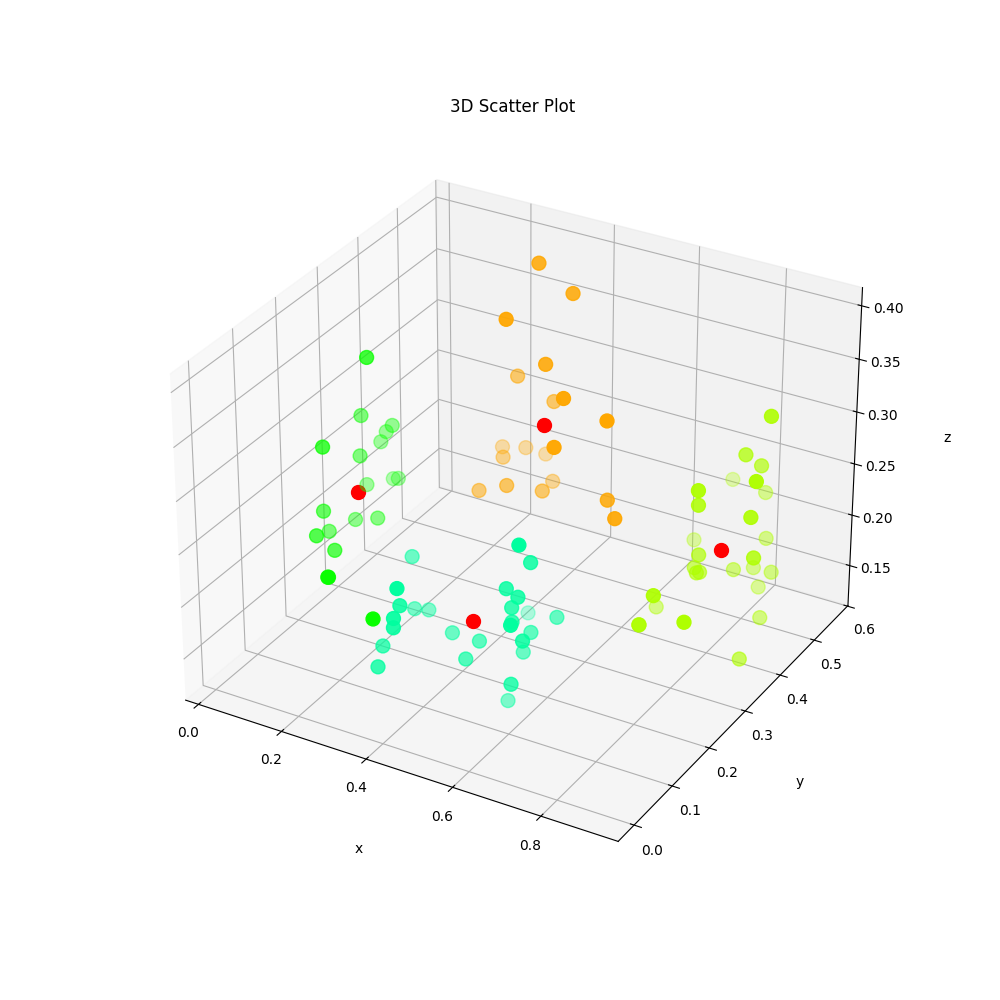

In [5]:
centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)


# Non-normalized data

In [6]:
# Clustering
number_of_clusters, clustered_data = clustering(data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
print(sorted_clusters, number_of_clusters)

[[  0.          57.73943666  14.12217556 128.        ]
 [  0.          57.75076219  18.62561078  92.        ]
 [  0.          57.42930805  14.09352221  92.        ]
 [  0.          57.66601141  18.42416965   2.        ]
 [  0.          58.39627115  15.08801677  96.        ]
 [  0.          56.83508407  13.97477716  28.        ]
 [  0.          56.8557736   16.7292357   29.        ]
 [  0.          57.95541683  19.22483659  25.        ]
 [  0.          58.72915215  15.55824031  31.        ]
 [  0.          56.99382914  13.76395693  92.        ]
 [  0.          57.03872123  14.51837914 101.        ]
 [  0.          58.25900661  15.69232137  92.        ]
 [  0.          58.65181654  16.0214216   12.        ]
 [  0.          57.50456805  18.43661352 104.        ]
 [  0.          58.66651782  16.32737215  13.        ]
 [  0.          56.1699989   15.46807348 201.        ]
 [  0.          56.57098423  13.91934301  34.        ]
 [  0.          56.96126794  16.37289757  91.        ]
 [  0.    

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[  1.          57.09275572  16.08729783 112.        ]
[  0.  45.  62. 171. 188. 200.]
1 57.53834118798006 14.995156162285989 74.91666666666667
2 57.45852292858494 15.21159898391249 49.28440366972477


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:103: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping wi

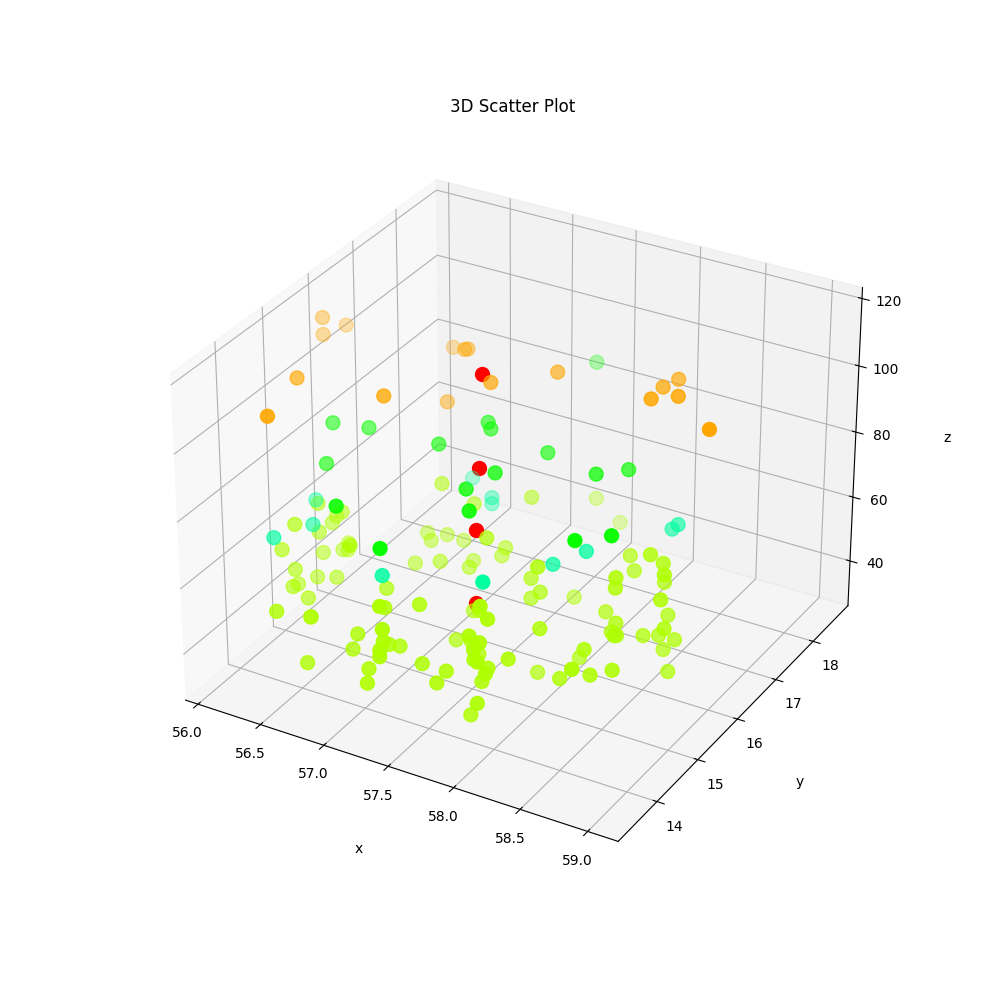

In [7]:
centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence

[  1.           0.34965473  16.08729783 112.        ]
[  0.  44.  61. 171. 188. 200.]
1 0.5006801663737783 14.995156162285989 74.91666666666667
2 0.474269147146836 15.217566490691361 49.46363636363636


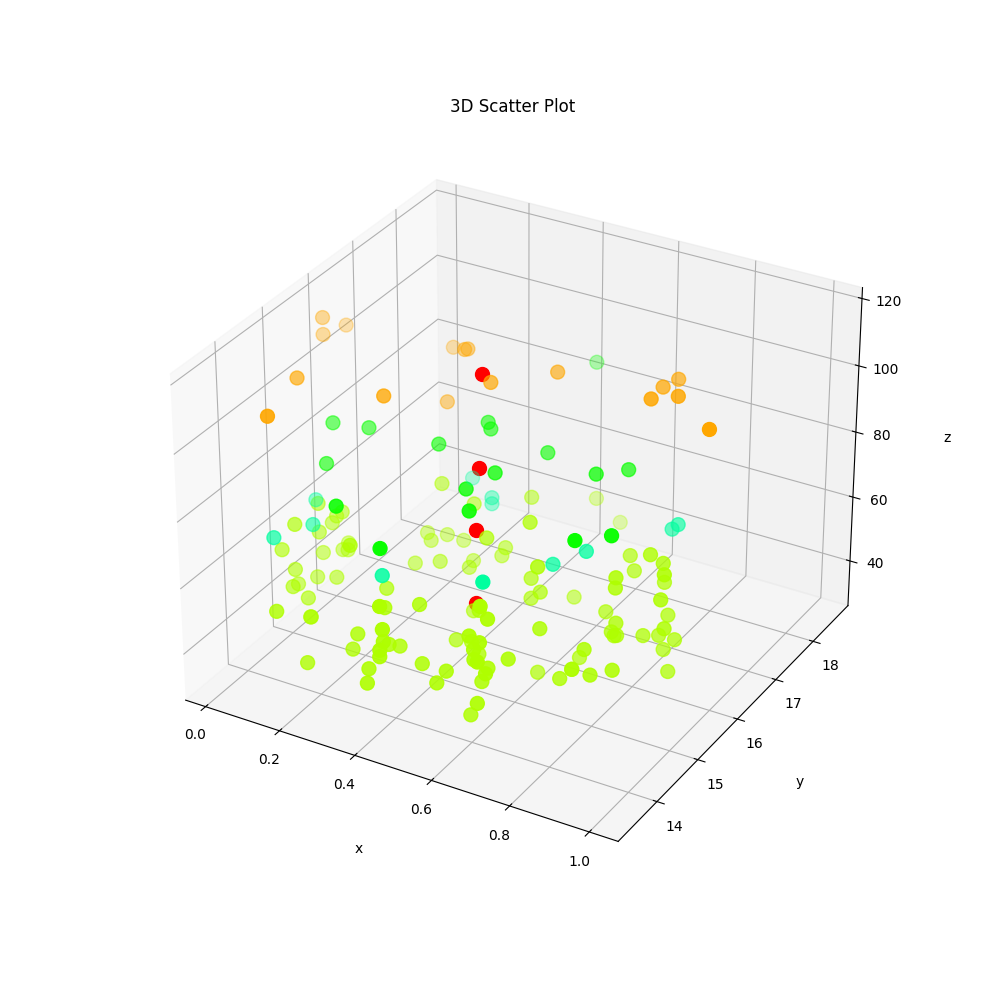

In [8]:
# Clustering
semi_norm_data = data
semi_norm_data[:, 0] = normalize_feature(data[:, 0])

number_of_clusters, clustered_data = clustering(semi_norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
# print(sorted_clusters, number_of_clusters)

centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence

[  1.           0.34965473   0.45642778 112.        ]
[  0.  44.  61. 170. 184. 200.]
1 0.46037558270389967 0.38183069712487594 84.8125
2 0.47362679825259024 0.30471473145165395 49.28440366972477


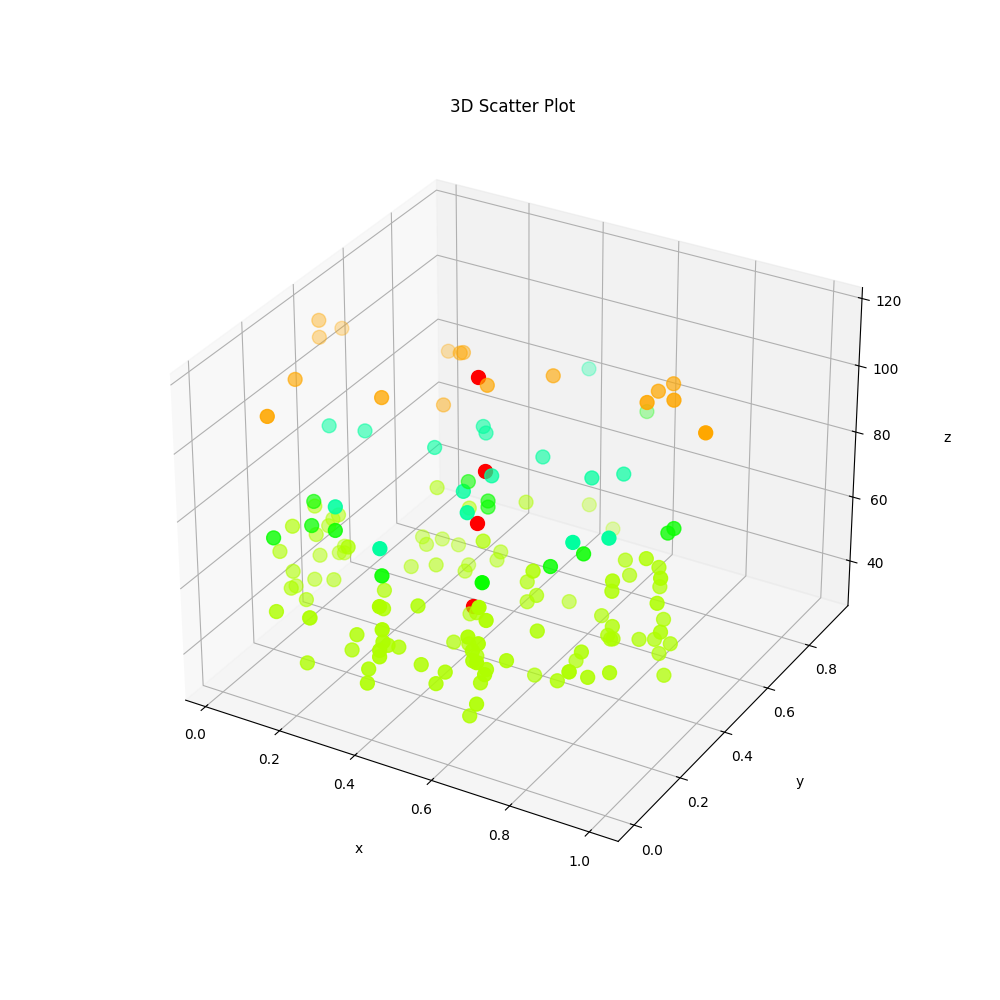

In [9]:
# Clustering
semi_norm_data = data
semi_norm_data[:, 0] = normalize_feature(data[:, 0])
semi_norm_data[:, 1] = normalize_feature(data[:, 1])


number_of_clusters, clustered_data = clustering(semi_norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
# print(sorted_clusters, number_of_clusters)

centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence

[[0.         0.56883888 0.11597433 0.5625    ]
 [0.         0.12834275 0.40186154 0.37053571]
 [0.         0.35474737 0.46165847 0.49107143]
 [0.         0.58414143 0.46670413 0.49107143]
 [0.         0.68413329 0.46794102 0.37053571]
 [0.         0.45086748 0.40787514 0.32142857]
 [0.         0.46372479 0.1110102  0.40178571]
 [0.         0.54395234 0.86128608 0.        ]
 [0.         0.79146445 0.28330436 0.41964286]
 [0.         0.57267752 0.89618534 0.40178571]
 [0.         0.46504736 0.28341532 0.37053571]
 [0.         0.26232025 0.09043786 0.11607143]
 [0.         0.62377003 0.3250681  0.13392857]
 [0.         0.89490623 0.46723669 0.33482143]
 [0.         0.03457186 0.36727972 0.51339286]
 [0.         0.13479075 0.01905686 0.49107143]
 [0.         0.2693327  0.56764221 0.12053571]
 [0.         0.04439211 0.38236023 0.37053571]
 [0.         0.13759566 0.02394652 0.23214286]
 [0.         0.52839056 0.19885356 0.375     ]
 [0.         0.17280702 0.08083401 0.14285714]
 [0.         

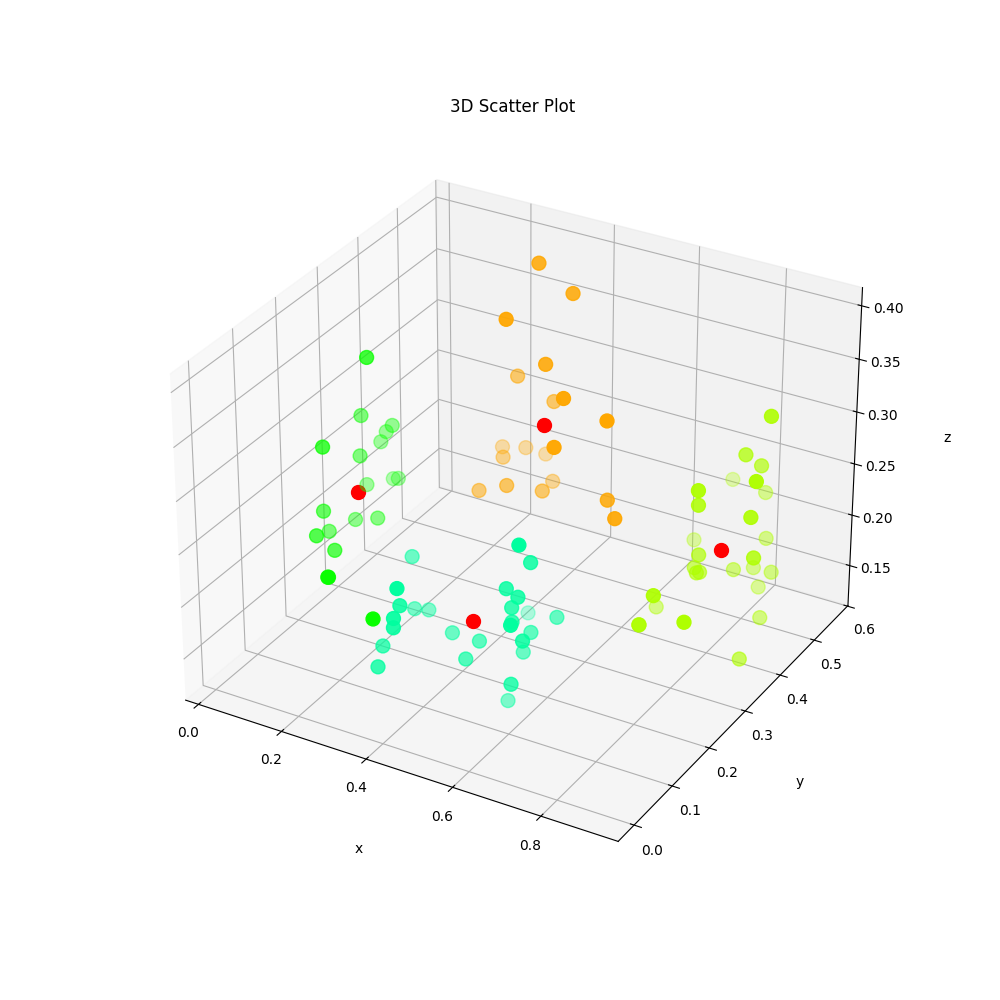

In [10]:
# Clustering
semi_norm_data = data
semi_norm_data[:, 0] = normalize_feature(data[:, 0])
semi_norm_data[:, 1] = normalize_feature(data[:, 1])
semi_norm_data[:, 2] = normalize_feature(data[:, 2])


number_of_clusters, clustered_data = clustering(semi_norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
print(sorted_clusters, number_of_clusters)

centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_33118/114156792.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence

[[0.         0.56883888 0.11597433 0.5625    ]
 [0.         0.12834275 0.40186154 0.37053571]
 [0.         0.35474737 0.46165847 0.49107143]
 [0.         0.58414143 0.46670413 0.49107143]
 [0.         0.68413329 0.46794102 0.37053571]
 [0.         0.45086748 0.40787514 0.32142857]
 [0.         0.46372479 0.1110102  0.40178571]
 [0.         0.54395234 0.86128608 0.        ]
 [0.         0.79146445 0.28330436 0.41964286]
 [0.         0.57267752 0.89618534 0.40178571]
 [0.         0.46504736 0.28341532 0.37053571]
 [0.         0.26232025 0.09043786 0.11607143]
 [0.         0.62377003 0.3250681  0.13392857]
 [0.         0.89490623 0.46723669 0.33482143]
 [0.         0.03457186 0.36727972 0.51339286]
 [0.         0.13479075 0.01905686 0.49107143]
 [0.         0.2693327  0.56764221 0.12053571]
 [0.         0.04439211 0.38236023 0.37053571]
 [0.         0.13759566 0.02394652 0.23214286]
 [0.         0.52839056 0.19885356 0.375     ]
 [0.         0.17280702 0.08083401 0.14285714]
 [0.         

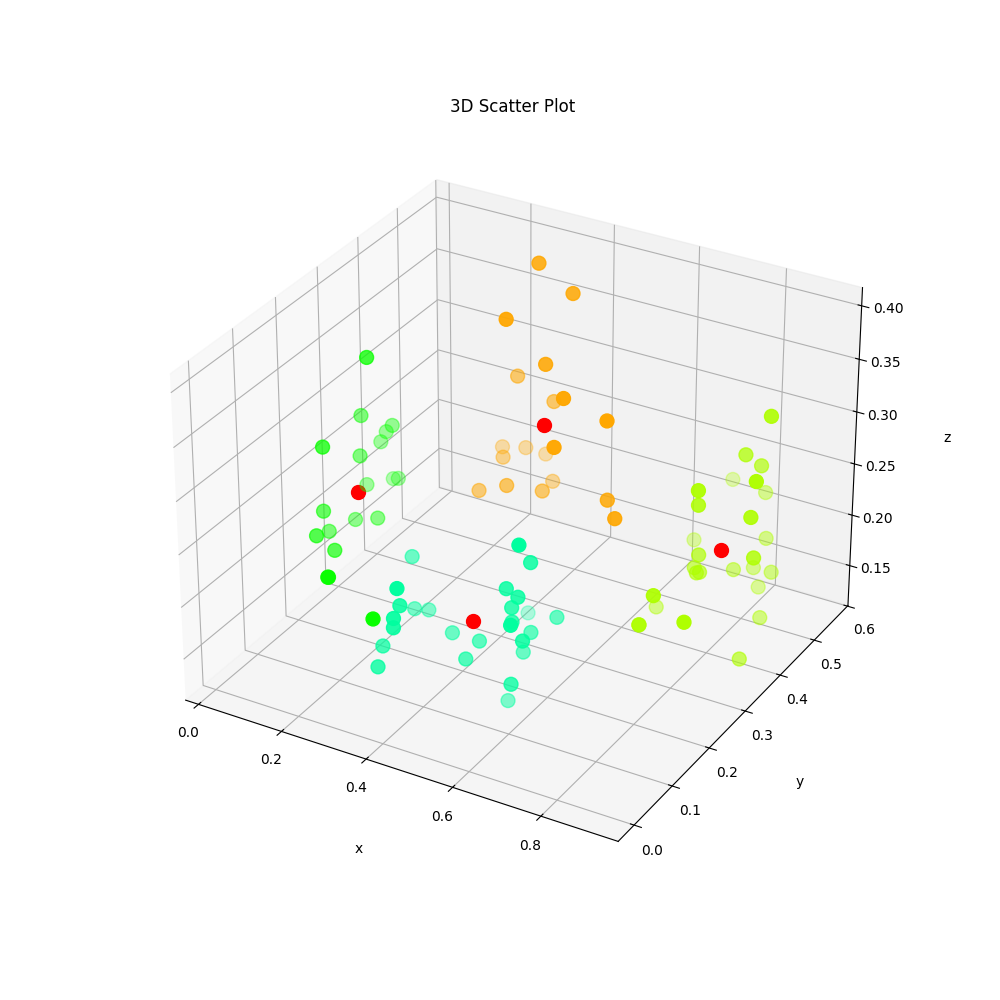

In [11]:
# Clustering
semi_norm_data = data
# semi_norm_data[:, 0] = normalize_feature(data[:, 0])
# semi_norm_data[:, 1] = normalize_feature(data[:, 1])
semi_norm_data[:, 2] = normalize_feature(data[:, 2])


number_of_clusters, clustered_data = clustering(semi_norm_data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
print(sorted_clusters, number_of_clusters)

centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass)